In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [19]:
data=pd.read_excel("crop_suggestions_all_india.xlsx")
data

,State,Soil Type,Temperature Range (°C),Season,Suggested Crops
0,Andhra Pradesh,Alluvial,5-10,Kharif,"Rice, Chillies, Tobacco, Cotton"
1,Andhra Pradesh,Alluvial,5-10,Rabi,"Rice, Chillies, Tobacco, Cotton"
2,Andhra Pradesh,Alluvial,5-10,Zaid,"Rice, Chillies, Tobacco, Cotton"
3,Andhra Pradesh,Alluvial,10-15,Kharif,"Rice, Chillies, Tobacco, Cotton"
4,Andhra Pradesh,Alluvial,10-15,Rabi,"Rice, Chillies, Tobacco, Cotton"
...,...,...,...,...,...
3019,Puducherry,Laterite,30-35,Rabi,"Rice, Sugarcane, Groundnut, Coconut"
3020,Puducherry,Laterite,30-35,Zaid,"Rice, Sugarcane, Groundnut, Coconut"
3021,Puducherry,Laterite,35-40,Kharif,"Rice, Sugarcane, Groundnut, Coconut"
3022,Puducherry,Laterite,35-40,Rabi,"Rice, Sugarcane, Groundnut, Coconut"


In [20]:
# data_1nf=(data.assign(**{"Suggested Crops": data["Suggested Crops"].str.split(",")}).explode("Suggested Crops"))
# data_1nf["Suggested Crops"]=data_1nf["Suggested Crops"].str.strip()
# data_1nf

In [21]:
data.describe()

,State,Soil Type,Temperature Range (°C),Season,Suggested Crops
count,3024,3024,3024,3024,3024
unique,36,4,7,3,32
top,Andhra Pradesh,Alluvial,5-10,Kharif,"Rice, Maize, Pulses, Oilseeds"
freq,84,756,432,1008,336


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   State                   3024 non-null   object
 1   Soil Type               3024 non-null   object
 2   Temperature Range (°C)  3024 non-null   object
 3   Season                  3024 non-null   object
 4   Suggested Crops         3024 non-null   object
dtypes: object(5)
memory usage: 118.3+ KB


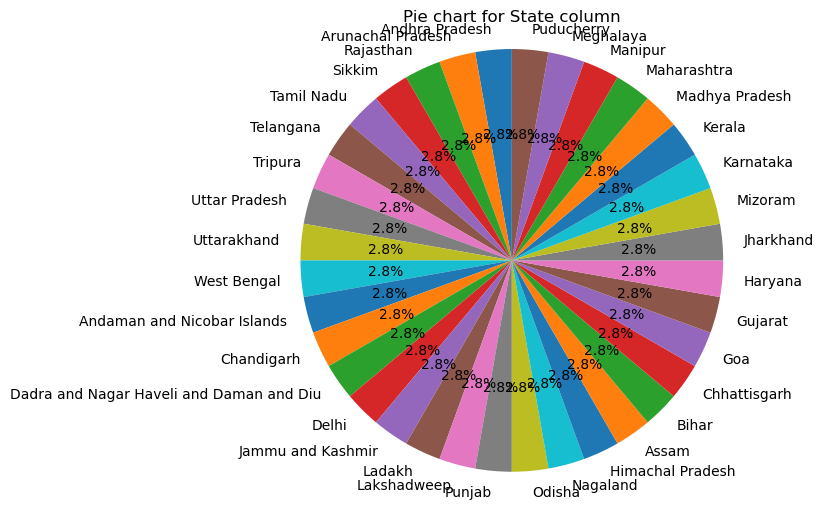

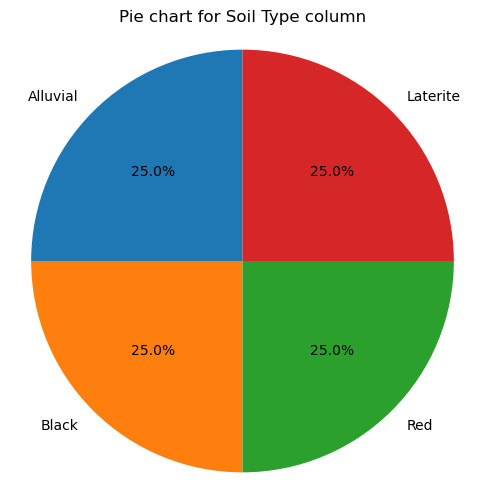

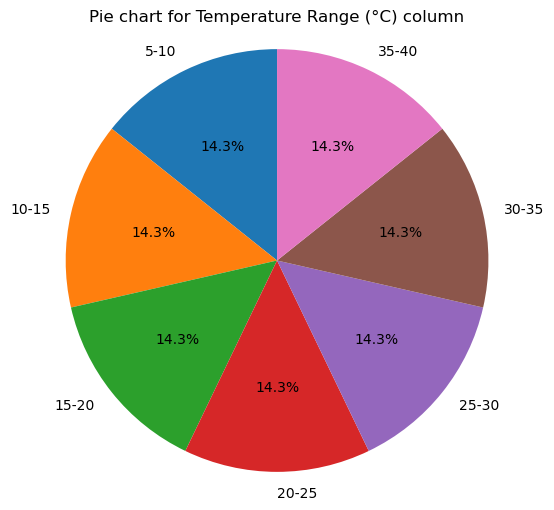

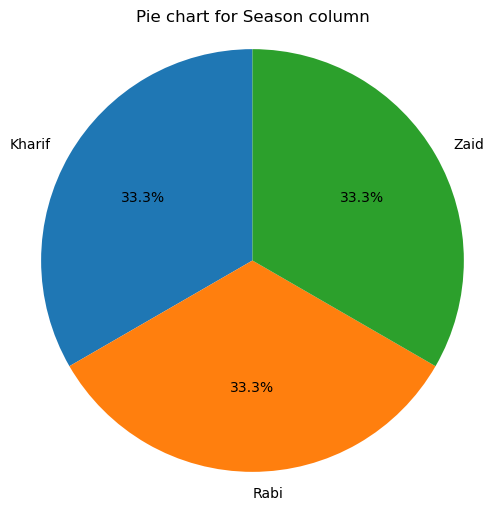

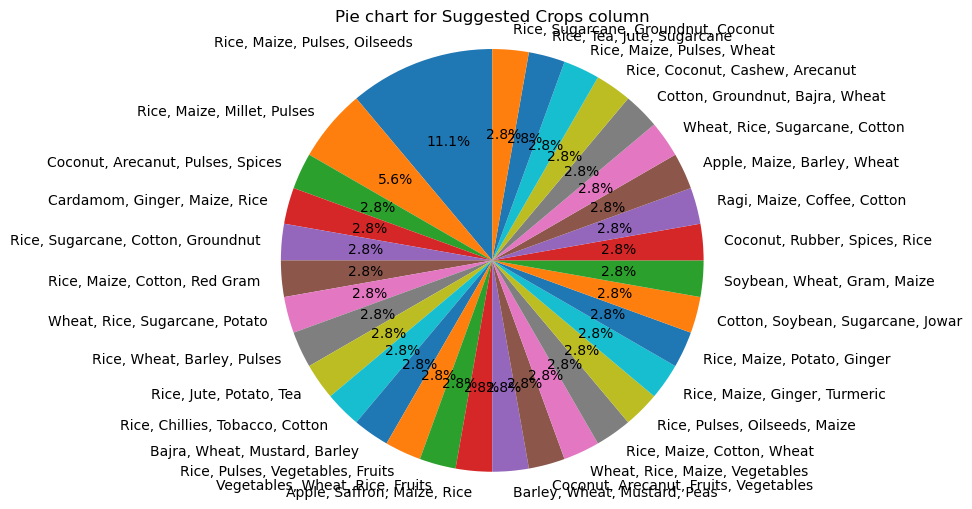

In [23]:
for col in data.columns:
    plt.figure(figsize=(6,6))
    counts=data[col].value_counts()
    plt.pie(counts,labels=counts.index,autopct='%1.1f%%',startangle=90)
    plt.title(f"Pie chart for {col} column")
    plt.axis("equal")
    plt.show()

In [24]:
le=LabelEncoder()
for col in data.columns:
    data[col]=le.fit_transform(data[col])

data

,State,Soil Type,Temperature Range (°C),Season,Suggested Crops
0,1,0,6,0,11
1,1,0,6,1,11
2,1,0,6,2,11
3,1,0,0,0,11
4,1,0,0,1,11
...,...,...,...,...,...
3019,26,2,4,1,24
3020,26,2,4,2,24
3021,26,2,5,0,24
3022,26,2,5,1,24


In [25]:
x=data.iloc[:,:4]
y=data["Suggested Crops"]

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.30,stratify=y)

In [27]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(2116, 4) (2116,)
(908, 4) (908,)


In [28]:
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)
print(y_train.shape, y_test.shape)

(2116, 32) (908, 32)


In [29]:
model=Sequential()
model.add(Dense(128,input_shape=(x_train.shape[1],),activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="softmax"))

C:\Users\Shubh Parmar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,976 (42.88 KB)

 Trainable params: 10,976 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [32]:
# model.fit(x_train,y_train,epochs=120,batch_size=10)

Epoch 1/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0895 - loss: 3.6556
Epoch 2/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1279 - loss: 2.8590
Epoch 3/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1782 - loss: 2.6370
Epoch 4/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1823 - loss: 2.5047
Epoch 5/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2218 - loss: 2.3029
Epoch 6/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2747 - loss: 2.1496
Epoch 7/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3051 - loss: 2.0208
Epoch 8/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3448 - loss: 1.8960
Epoch 9/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3650 - loss: 1.7979
Epoch 10/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4076 - loss: 1.7242
Epoch 11/120
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4085 - loss: 1.6380
Epoch 12/120
212/212 ━━━━━━━━━━━━━━━━━━━━

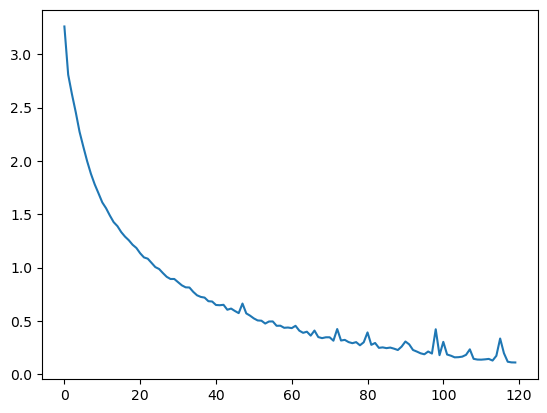

In [33]:
history=model.fit(x_train,y_train,epochs=120,batch_size=10)
loss=history.history["loss"]
plt.plot(loss)

In [34]:
y_pred=model.predict(x_test)
y_pred

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.0000000e+00, 0.0000000e+00, 1.1156544e-03, ..., 7.9767156e-26,
        0.0000000e+00, 1.6003916e-28],
       [0.0000000e+00, 0.0000000e+00, 5.4187745e-01, ..., 3.0659707e-27,
        0.0000000e+00, 1.8168939e-13],
       [6.1470305e-20, 0.0000000e+00, 0.0000000e+00, ..., 1.4151239e-07,
        1.5944219e-30, 0.0000000e+00],
       ...,
       [0.0000000e+00, 9.9158554e-33, 0.0000000e+00, ..., 1.0885631e-11,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 5.9889336e-03, ..., 4.2154785e-27,
        0.0000000e+00, 6.1409771e-08],
       [2.0131937e-03, 2.2047033e-13, 0.0000000e+00, ..., 1.4072594e-26,
        9.9791712e-01, 0.0000000e+00]], dtype=float32)

In [35]:
y_pred=(y_pred>=0.5).astype(int)
y_pred

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]])

In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred_classes=np.argmax(y_pred, axis=1)
y_true=np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred_classes))
print(accuracy_score(y_true, y_pred_classes))

[[25  0  0 ...  0  0  0]
 [ 0 25  0 ...  0  0  0]
 [ 0  0 25 ...  0  0  0]
 ...
 [ 0  0  0 ... 25  0  0]
 [ 0  0  0 ...  0 25  0]
 [ 0  0  0 ...  0  0 25]]
0.9493392070484582


In [37]:
model.save("NN_Model.h5")

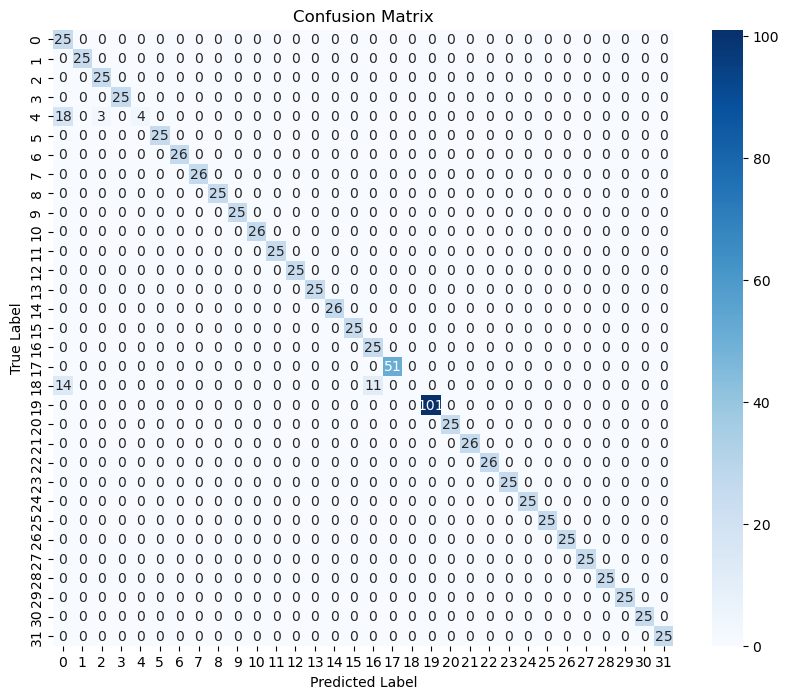

In [40]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred_classes),cmap="Blues",fmt="d",annot=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()